In [208]:
from typing import List
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
import matplotlib.pyplot as plt
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.aquarium_domain as aq
import src.models.mlp_model as mm

In [209]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_TEMP_SAVE_PATH = './most_eff_model.pt'
NU = 1 / 1
RE = 10 / NU
T_MAX = 1
L_BOUNDS = [-5.0, -5.0]
U_BOUNDS = [5.0, 5.0]
A = 0.3 

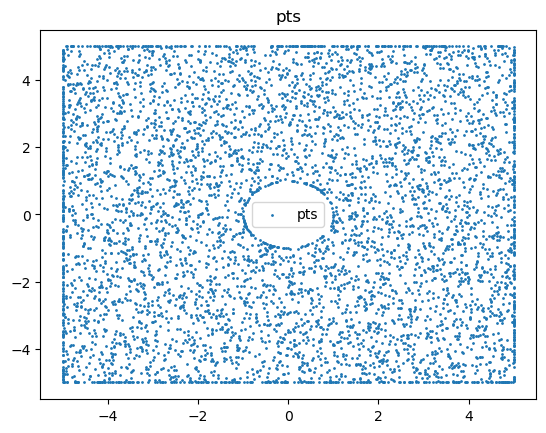

In [210]:
domain_ctx = aq.AquariumContext(
    dim=2,
    l_bounds=(-5, -5),
    u_bounds=(5, 5),
    N_int=5_000,
    N_sides=[(200, 200), (200, 200)],
    int_sampling='Latin',
    device=device,
    ball_centre=torch.tensor([0.0, 0.0], device=device),
    ball_r=1,
    ball_N=100
)

domain = aq.AquariumDomain(domain_ctx)
domain.generate_points()

utils.plot_points({"pts": domain.get_all_points()}, "pts")

In [211]:
model_ctx = mm.ModelContext(
    input_dim=2,
    output_dim=1, 
    layer = [50, 50],
    u_bounds=U_BOUNDS,
    l_bounds=L_BOUNDS
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=200, factor=0.9)

In [212]:
def pde_res(psi: torch.Tensor, x: torch.Tensor):
    psi_grad = grad(psi, x, torch.ones_like(psi), create_graph=True)[0]
    u, v = psi_grad[:, 1:2], -psi_grad[:, 0:1]
    
    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y = u_grad[:, 0:1], u_grad[:, 1:2]
    v_x, v_y = v_grad[:, 0:1], v_grad[:, 1:2]
    
    u_xx = grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, x, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, x, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    res_a = u * u_x + v * u_y - NU * (u_xx + u_yy)
    res_b = u * v_x + v * v_y - NU * (v_xx + v_yy)
                
    return res_a, res_b

In [ ]:
C = 1e6

def loss(model: torch.nn.Module, domain: aq.AquariumDomain):
    pde_pts = domain.interior.requires_grad_(True)
    pde_psi = model(pde_pts)
    pde_res_a, pde_res_b = pde_res(pde_psi, pde_pts)
    pde_loss = torch.mean(pde_res_a**2 + pde_res_b**2)
        
    pde_res_b_x = grad(pde_res_b, pde_pts, torch.ones_like(pde_res_b), create_graph=True)[0][:, 0:1]
    pde_res_a_y = grad(pde_res_a, pde_pts, torch.ones_like(pde_res_a), create_graph=True)[0][:, 1:2]
    eqm_loss = torch.mean((pde_res_b_x - pde_res_a_y)**2)

    side_pts = torch.cat([
        domain.sides[0][0],
        domain.sides[0][1],
        domain.sides[1][0],
        domain.sides[1][1],
    ], dim=0).requires_grad_(True)
        
    side_psi = model(side_pts)
    side_psi_grad = grad(side_psi, side_pts, torch.ones_like(side_psi), create_graph=True)[0]
    side_u, side_v = side_psi_grad[:, 1:2], -side_psi_grad[:, 0:1]
    side_loss = torch.mean((side_u - 1)**2 + (side_v)**2)
    
    ball_pts = domain.ball_boundary.requires_grad_(True)
    ball_psi = model(ball_pts)
    ball_psi_grad = grad(ball_psi, ball_pts, torch.ones_like(ball_psi), create_graph=True)[0]
    ball_vel_n = torch.sum(ball_pts * ball_psi_grad, dim=1)
    ball_loss = torch.mean((ball_vel_n)**2)

    return [pde_loss, C*eqm_loss, C*side_loss, C*ball_loss]

In [214]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss,
    epochs=30_000,
    scheduler=scheduler,
    monitor_lr=True
)

total_loss_values_1, component_loss_values_1 = train.simple_train(train_ctx)

Loss at epoch 1 is: 1.0972241163253784. Current learing rate: 0.001 
Loss at epoch 100 is: 0.4654395580291748. Current learing rate: 0.001 
Loss at epoch 200 is: 0.3897334933280945. Current learing rate: 0.001 
Loss at epoch 300 is: 0.3609909415245056. Current learing rate: 0.001 
Loss at epoch 400 is: 0.32247406244277954. Current learing rate: 0.001 
Loss at epoch 500 is: 0.30959564447402954. Current learing rate: 0.001 
Loss at epoch 600 is: 0.2658233642578125. Current learing rate: 0.001 
Loss at epoch 700 is: 0.23132649064064026. Current learing rate: 0.001 
Loss at epoch 800 is: 0.24317869544029236. Current learing rate: 0.001 
Loss at epoch 900 is: 0.23742592334747314. Current learing rate: 0.001 
Loss at epoch 1000 is: 0.23157209157943726. Current learing rate: 0.001 
Loss at epoch 1100 is: 0.19344986975193024. Current learing rate: 0.0009000000000000001 
Loss at epoch 1200 is: 0.18796992301940918. Current learing rate: 0.0009000000000000001 
Loss at epoch 1300 is: 0.22827160358

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


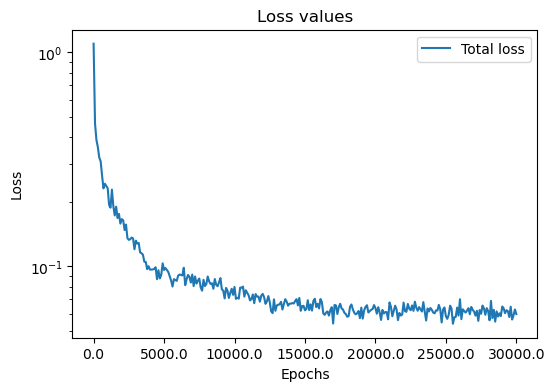

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/nav_stokes/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


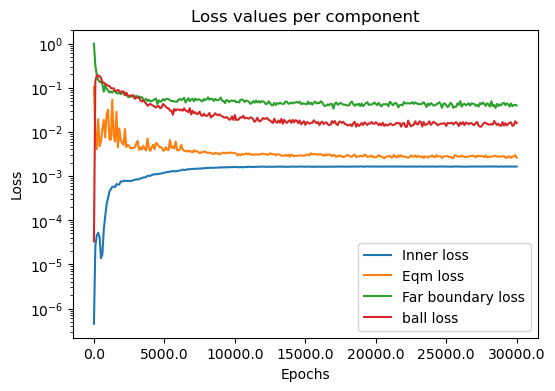

In [218]:
# vykresleni vyvoje ztraty
plot_context = utils.PlotContext(
    u_bounds=domain_ctx.u_bounds,
    l_bounds=domain_ctx.l_bounds,
    figsize=(8,6),
    patches=None,
    device=device,
    vmin=0,
    vmax=2,
    N=100,
    titles=['Velocity norm'],
    function_names=['u'],
    x_label='Epochs',
    y_label='Loss'
)

plot_context.titles = ["Loss values"]
utils.plot_loss_values({'Total loss': total_loss_values_1}, plot_context)
plot_context.titles = ["Loss values per component"]
utils.plot_loss_values({'Inner loss': component_loss_values_1[0],
                        'Eqm loss': component_loss_values_1[1],
                        'Far boundary loss': component_loss_values_1[2],
                        'ball loss': component_loss_values_1[3]}, plot_context)


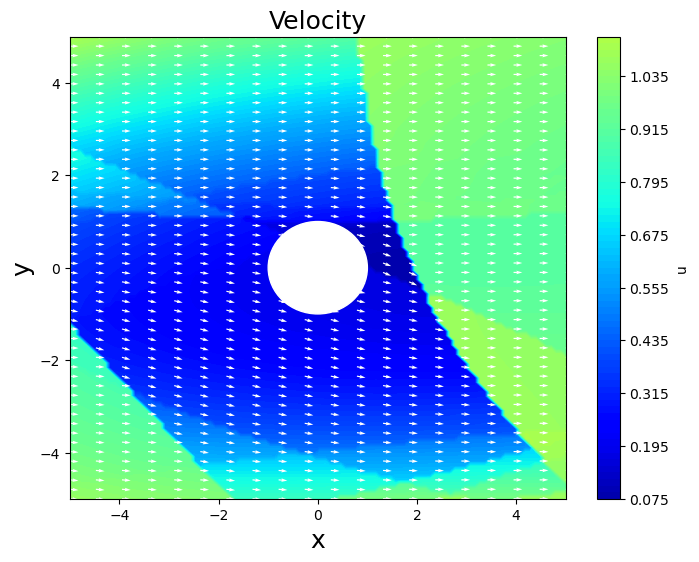

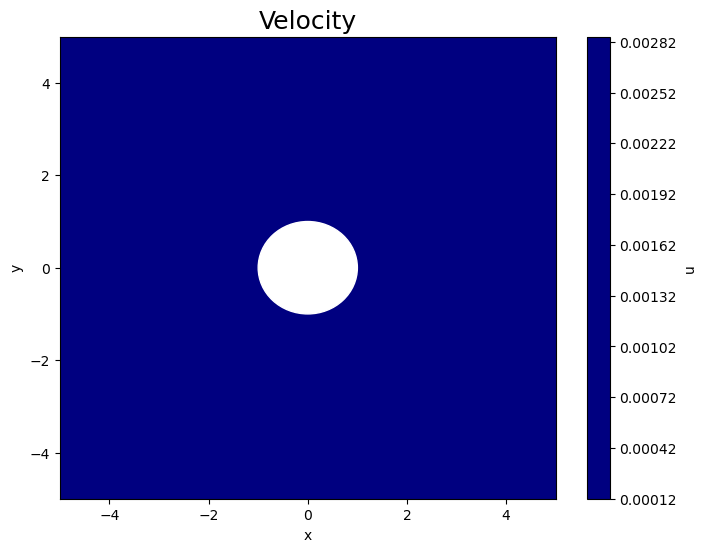

In [217]:
# vykresleni rychlosti kapaliny
plot_context.patches = [plt.Circle((0.0, 0.0), 1.0, color="white", zorder=10)]
plot_context.titles = ['Velocity']
plot_context.function_names = ['u']
plot_context.x_label = 'x'
plot_context.y_label = 'y'
plot_context.fontsize = 18

def psi_analytic(x):
    return (1 - 1/(x[:, 0]**2 + x[:, 1]**2)) * x[:, 1]

def u(x: torch.Tensor): 
    x.requires_grad_(True)
    psi = model(x)
    psi_grad = torch.clamp(grad(psi, x, torch.ones_like(psi), create_graph=False)[0], 0.0, 5)
    
    return torch.cat([psi_grad[:, 1:2], -psi_grad[:, 0:1]], dim=1)

def res(x):
    x.requires_grad_(True)
    psi = model(x)
    res_a, res_b = pde_res(psi, x)
    
    return res_a**2 + res_b**2


utils.plot_vector_field_2d([u], plot_context, N=100, n_heigth=50, n_width=20)
plot_context.patches = [plt.Circle((0.0, 0.0), 1.0, color="white", zorder=10)]
utils.plot_function_on_2d_cube([res], plot_context)